In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("datasets/emails.csv")

In [33]:
df.head(), df.tail()

(                                                text  spam  \
 0  Subject: naturally irresistible your corporate...     1   
 1  Subject: the stock trading gunslinger  fanny i...     1   
 2  Subject: unbelievable new homes made easy  im ...     1   
 3  Subject: 4 color printing special  request add...     1   
 4  Subject: do not have money , get software cds ...     1   
 
                                              message  
 0  naturally irresistible your corporate identity...  
 1  the stock trading gunslinger  fanny is merrill...  
 2  unbelievable new homes made easy  im wanting t...  
 3  4 color printing special  request additional i...  
 4  do not have money , get software cds from here...  ,
                                                    text  spam  \
 5723  Subject: re : research and development charges...     0   
 5724  Subject: re : receipts from visit  jim ,  than...     0   
 5725  Subject: re : enron case study update  wow ! a...     0   
 5726  Subject: re 

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5728 non-null   object
 1   spam    5728 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 89.6+ KB


In [7]:
df["spam"].value_counts()

spam
0    4360
1    1368
Name: count, dtype: int64

In [8]:
df.isna().sum()

text    0
spam    0
dtype: int64

In [9]:
df["message"] = df["text"].str.replace(r"^Subject:\s*", "", regex=True)
df.head()

,text,spam,message
0,Subject: naturally irresistible your corporate...,1,naturally irresistible your corporate identity...
1,Subject: the stock trading gunslinger fanny i...,1,the stock trading gunslinger fanny is merrill...
2,Subject: unbelievable new homes made easy im ...,1,unbelievable new homes made easy im wanting t...
3,Subject: 4 color printing special request add...,1,4 color printing special request additional i...
4,"Subject: do not have money , get software cds ...",1,"do not have money , get software cds from here..."


In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X = df["message"]
y = df["spam"]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer

In [14]:
model = Pipeline([
    ("vectorizer", CountVectorizer()),
    ("nb", MultinomialNB())
])

In [15]:
model.fit(X_train, y_train)

,steps,"[('vectorizer', ...), ('nb', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [18]:
y_pred = model.predict(X_test)

In [17]:
from sklearn.metrics import (roc_curve, roc_auc_score, confusion_matrix, classification_report)

In [20]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       856
           1       0.98      0.97      0.98       290

    accuracy                           0.99      1146
   macro avg       0.98      0.98      0.98      1146
weighted avg       0.99      0.99      0.99      1146



In [31]:
custom = ['''Dear Saptaswa Sen,
Thank you for being a valued investor in UTI Mutual Fund. We truly appreciate our relationship for over 0.6 years and are committed to creating long-term wealth for you.
Starting an SIP is easy, like booking a trip online set it up and watch your investment grow.
Join 16* lakh investors who are already on their SIP journey with UTI Mutual Fund. With just Rs. 500# a month, take that first step towards achieving your financial goals today.''']

In [47]:
model.predict(custom)

array([1])

In [46]:
custom = ["Alert 50%: data is consumed. Get 3GB per day for 3 days at Rs. 39. Recharge now i.airtel.in/dtpck-pre"]

In [50]:
model.predict(custom)

array([0])

In [48]:
custom = ['''Greetings, students
          Please find the attached assignment below.
''']

In [49]:
model.predict(custom)

array([0])

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
cm = confusion_matrix(y_pred, y_test)

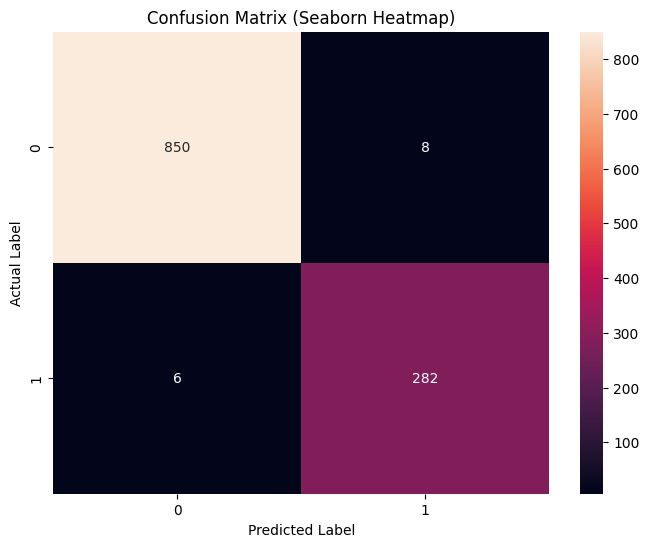

In [43]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix (Seaborn Heatmap)')
plt.show()

In [ ]:
y_proba = model.predict_proba(X_test)[:, 1]

array([4.90715947e-135, 5.81783292e-011, 1.23807016e-073, ...,
       1.00000000e+000, 1.52773380e-094, 5.05814953e-088], shape=(1146,))

In [37]:
y_proba

array([4.90715947e-135, 5.81783292e-011, 1.23807016e-073, ...,
       1.00000000e+000, 1.52773380e-094, 5.05814953e-088], shape=(1146,))

In [36]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

In [38]:
fpr, tpr, thresholds

(array([0.        , 0.00350467, 0.00350467, 0.00350467, 0.00350467,
        0.00350467, 0.0046729 , 0.0046729 , 0.00700935, 0.00700935,
        0.00817757, 0.00817757, 0.01285047, 0.01285047, 0.01752336,
        0.01752336, 0.125     , 0.12733645, 0.20443925, 0.20443925,
        0.62383178, 0.62616822, 0.70093458, 0.70327103, 0.84228972,
        0.84462617, 0.85046729, 0.85280374, 0.93925234, 0.94158879,
        0.9521028 , 1.        ]),
 array([0.        , 0.72068966, 0.73448276, 0.74827586, 0.75517241,
        0.88275862, 0.88275862, 0.96551724, 0.96551724, 0.97586207,
        0.97586207, 0.98275862, 0.98275862, 0.99310345, 0.99310345,
        0.99655172, 0.99655172, 0.99655172, 0.99655172, 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        ]),
 array([            inf, 1.00000000e+000, 1.00000000e+000, 1.00000000e+000,
        1.00000000e+000, 9.99999854e-001

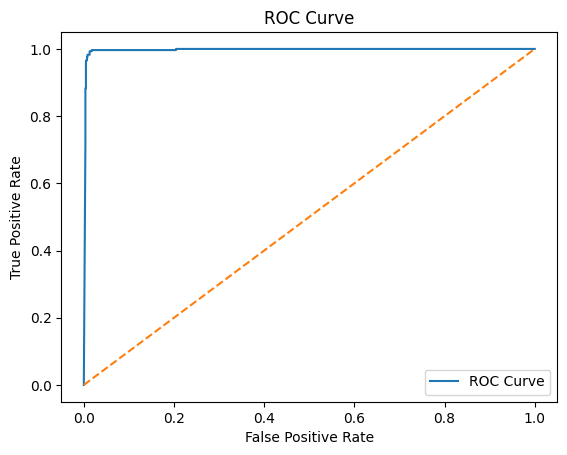

In [39]:
plt.figure()

plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()

In [40]:
auc_score = roc_auc_score(y_test, y_proba)

print("AUC Score:", auc_score)

AUC Score: 0.9967551563003545
